In [16]:
# --- Step 1: Library Import ---
# use pandas for data manipulation and numpy for handling missing values (NaN)
import pandas as pd
import numpy as np

# --- Step 2: Create Synthetic Raw Data ---
# Simulating a real-world scenario where sensors might fail (resulting in NaNs)
raw_data = {
    "timestamp": [0, 1, 2, 3, 4, 5, 6],
    "pressure_bar": [101.3, 102.5, np.nan, 103.1, 350.0, np.nan, 101.8],
    "temperature_c": [22.1, 22.4, 23.0, np.nan, 45.0, 22.8, 22.5]
}

# Initialize the DataFrame
df_raw = pd.DataFrame(raw_data)

# Preview the raw data with missing values
print("Raw Data Preview:")
print(df_raw)

Raw Data Preview:
   timestamp  pressure_bar  temperature_c
0          0         101.3           22.1
1          1         102.5           22.4
2          2           NaN           23.0
3          3         103.1            NaN
4          4         350.0           45.0
5          5           NaN           22.8
6          6         101.8           22.5


In [17]:
# --- Step 3: Check for missing values (NaN) ---
# .isna() identifies null values, .sum() counts them per column
missing_values_count = df_raw.isna().sum()

print("--- Data Integrity Report ---")
print("Number of missing values in each column:")
print(missing_values_count)

# Optional: Calculate the percentage of missing data
total_rows = len(df_raw)
missing_percentage = (missing_values_count / total_rows) * 100
print("\nPercentage of missing data (%):")
print(missing_percentage)

--- Data Integrity Report ---
Number of missing values in each column:
timestamp        0
pressure_bar     2
temperature_c    1
dtype: int64

Percentage of missing data (%):
timestamp         0.000000
pressure_bar     28.571429
temperature_c    14.285714
dtype: float64


In [18]:
# --- Step 4: Data Imputation (Filling the Gaps) ---

# 1. Best Practice: Create a copy of the dataframe
# This ensures don't accidentally mess up the raw data
df_cleaned = df_raw.copy()

# 2. Calculate the average (mean) for each sensor column
# Note: Pandas .mean() automatically ignores NaN values
avg_pressure = df_cleaned["pressure_bar"].mean()
avg_temp = df_cleaned["temperature_c"].mean()

print(f"Calculated Mean Pressure: {avg_pressure:.2f} bar")
print(f"Calculated Mean Temperature: {avg_temp:.2f} C")

# 3. Fill the NaNs with the calculated mean values
# The .fillna() method targets only the 'NaN' cells
df_cleaned["pressure_bar"] = df_cleaned["pressure_bar"].fillna(avg_pressure)
df_cleaned["temperature_c"] = df_cleaned["temperature_c"].fillna(avg_temp)

# 4. Final Verification: Check if any NaNs remain
print("\n--- Verification After Cleaning ---")
print(df_cleaned.isna().sum())

# Display the final cleaned table
df_cleaned

Calculated Mean Pressure: 151.74 bar
Calculated Mean Temperature: 26.30 C

--- Verification After Cleaning ---
timestamp        0
pressure_bar     0
temperature_c    0
dtype: int64


,timestamp,pressure_bar,temperature_c
0,0,101.30,22.1
1,1,102.50,22.4
2,2,151.74,23.0
3,3,103.10,26.3
4,4,350.00,45.0
5,5,151.74,22.8
6,6,101.80,22.5


In [19]:
# --- Step 5: Save the cleaned data ---
# We use index=False so we don't save the row numbers 0,1,2...
df_cleaned.to_csv("cleaned_sensor_data_v1.csv", index=False)

print("Final Step Complete: Cleaned data saved as 'cleaned_sensor_data_v1.csv'")

Final Step Complete: Cleaned data saved as 'cleaned_sensor_data_v1.csv'


In [20]:
# Import Libraries and Load Data ---
# matplotlib.pyplot is the standard library for data visualization in Python
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset from our previous step
# Ensure the file 'cleaned_sensor_data_v1.csv' is in the same directory
df = pd.read_csv("cleaned_sensor_data_v1.csv")

# Basic Plotting (Pressure Trend) ---
# Initialize a figure with a professional aspect ratio (10x5 inches)
plt.figure(figsize=(10, 5))

# Plot the 'pressure_bar' against 'timestamp_s'
# This creates a basic line chart connecting the data points
plt.plot(df["timestamp_s"], df["pressure_bar"])

# Display the plot in the notebook
plt.show()

KeyError: 'timestamp_s'

<Figure size 1000x500 with 0 Axes>

In [ ]:
# Check the exact column names in your dataframe
print(df.columns.tolist())


['timestamp', 'pressure_bar', 'temperature_c']


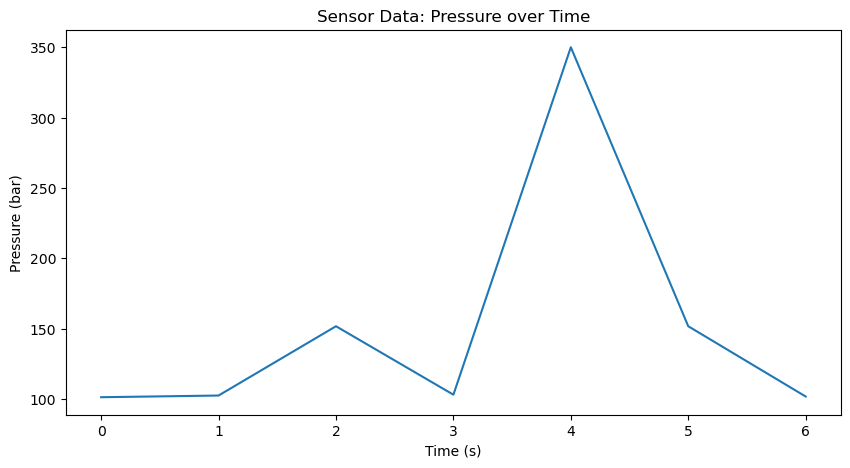

In [ ]:
#  Visualization of Pressure Trend ---
# Setting the figure size for better visibility
plt.figure(figsize=(10, 5))

# Plotting 'pressure_bar' using 'timestamp' as the X-axis
# Note: Ensure the column names match the list we just printed
plt.plot(df["timestamp"], df["pressure_bar"])

# Adding labels and title (Crucial for any technical report)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (bar)")
plt.title("Sensor Data: Pressure over Time")

# Display the plot
plt.show()

Success: Plot saved as 'sensor_analysis_plot.png'


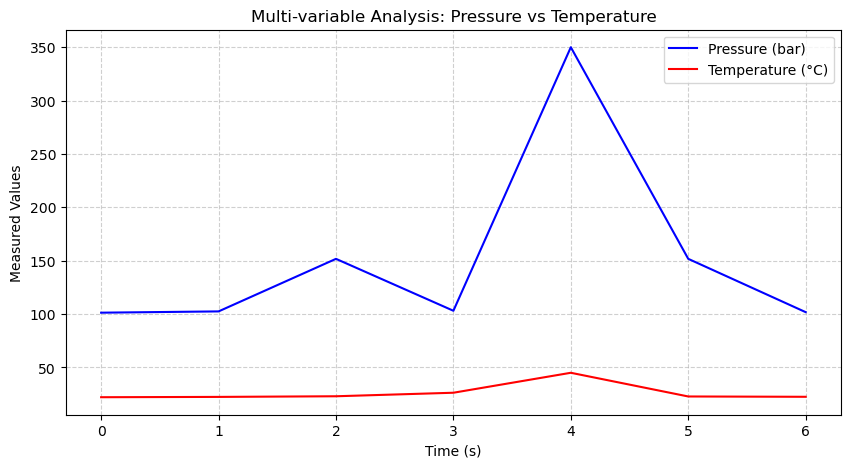

In [ ]:
# Overlaying Temperature and Adding a Legend ---

#  Start with the same figure setup
plt.figure(figsize=(10, 5))

#  Plot Pressure (keep it blue)
# We add a 'label' here so the legend knows what to call this line
plt.plot(df["timestamp"], df["pressure_bar"], color="blue", label="Pressure (bar)")

#  Plot Temperature (let's use red for heat)
# This will be drawn on the SAME coordinate system
plt.plot(df["timestamp"], df["temperature_c"], color="red", label="Temperature (°C)")

#  Add the "Instruction Manual" (The Legend)
# This command automatically creates a box showing our labels
plt.legend()

# Adding the same professional labels as before
plt.xlabel("Time (s)")
plt.ylabel("Measured Values")
plt.title("Multi-variable Analysis: Pressure vs Temperature")
plt.grid(True, linestyle='--', alpha=0.6) # Add a subtle grid for better readability

plt.savefig("sensor_analysis_plot.png", dpi=300, bbox_inches='tight')

print("Success: Plot saved as 'sensor_analysis_plot.png'")

plt.show()

In [ ]:
# --- Step 1 & 2: Statistical Analysis for Pressure ---

# Calculate basic statistics for Pressure
pressure_mean = df["pressure_bar"].mean()
pressure_std  = df["pressure_bar"].std()
pressure_max  = df["pressure_bar"].max()
pressure_min  = df["pressure_bar"].min()

# Display the results in a formatted way
print("--- Pressure Statistics ---")
print(f"Mean: {pressure_mean:.2f} bar")
print(f"Std Dev: {pressure_std:.2f}")
print(f"Max: {pressure_max:.2f} bar")
print(f"Min: {pressure_min:.2f} bar")

NameError: name 'df' is not defined

In [ ]:
df = pd.read_csv("cleaned_sensor_data_v1.csv")

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plot

In [ ]:
# Statistical Analysis for Pressure ---

# Calculate basic statistics for Pressure
pressure_mean = df["pressure_bar"].mean()
pressure_std  = df["pressure_bar"].std()
pressure_max  = df["pressure_bar"].max()
pressure_min  = df["pressure_bar"].min()

# Display the results in a formatted way
print("--- Pressure Statistics ---")
print(f"Mean: {pressure_mean:.2f} bar")
print(f"Std Dev: {pressure_std:.2f}")
print(f"Max: {pressure_max:.2f} bar")
print(f"Min: {pressure_min:.2f} bar")

NameError: name 'df' is not defined

In [ ]:
df = pd.read_csv("cleaned_sensor_data_v1.csv")

In [ ]:
pressure_mean = df["pressure_bar"].mean()
pressure_std  = df["pressure_bar"].std()
pressure_max  = df["pressure_bar"].max()
pressure_min  = df["pressure_bar"].min()

# Display the results in a formatted way
print("--- Pressure Statistics ---")
print(f"Mean: {pressure_mean:.2f} bar")
print(f"Std Dev: {pressure_std:.2f}")
print(f"Max: {pressure_max:.2f} bar")
print(f"Min: {pressure_min:.2f} bar")

--- Pressure Statistics ---
Mean: 151.74 bar
Std Dev: 90.49
Max: 350.00 bar
Min: 101.30 bar


In [ ]:
print(f"Mean:{pressure_mean:.2f} bar")

Mean:151.74 bar


In [ ]:
### 📝 Data Analysis Summary
- **Pressure Anomaly:** The maximum pressure (350 bar) is significantly higher than the average, indicating a potential system spike.
- **Thermal Stability:** The temperature remains relatively stable with a low standard deviation, suggesting consistent cooling performance.

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("data_with_nan.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data_with_nan.csv'

In [ ]:
df = pd.read_csv("data.csv")

In [ ]:
df["pressure"] = df["pressure"].fillna(df["pressure"].mean())
df["temperature"] = df["temperature"].fillna(df["temperature"].mean())

print("Data loaded and cleaned successfully!")
df.head()

KeyError: 'temperature'

In [ ]:
print(df.columns)

Index(['time', 'pressure'], dtype='object')


In [ ]:
for file in os.listdir():
    if file.endswith(".csv"):
        try:
            temp_df = pd.read_csv(file)
            print(f"File: {file} | Columns: {list(temp_df.columns)}")
        except:
            pass

NameError: name 'os' is not defined

In [ ]:
import pandas as pd
import os
print("--- Searching for your columns ---")
for file in os.listdir():
    if file.endswith(".csv"):
        try:
            temp_df = pd.read_csv(file)
            print(f"File: {file} -> Columns: {list(temp_df.columns)}")
        except:
            pass

--- Searching for your columns ---
File: cleaned_sensor_data_v1.csv -> Columns: ['timestamp', 'pressure_bar', 'temperature_c']
File: data.csv -> Columns: ['time', 'pressure']


In [ ]:
import pandas as pd
df = pd.read_csv("cleaned_sensor_data_v1.csv")

In [ ]:
mean_p=df["pressure_bar"].mean()
std_p=df["pressure_bar"].std()
threshold=mean_p+2*std_p

In [ ]:
print(f"---statistics for pressure")
print(f"mean:{mean_p:.2f}|Std:{std_p:.2f}|Threshold:{threshold:.2f}")

---statistics for pressure
mean:151.74|Std:90.49|Threshold:332.73


In [ ]:
mean_t=df["temperature_c"].mean()
std_t=df["temperature_c"].std()
threshold_t=mean_t+2*std_t

In [ ]:
print(f"---statistics for temperature")
print(f"mean:{mean_t:.2f}|Std_t:{std_t:2f}|Threschold:{threshold_t:.2f}")

---statistics for temperature
mean:26.30|Std_t:8.367795|Threschold:43.04


In [ ]:
def detect_anomalies(data, threshold):
    anomaly_index = []
    for i in range(len(data)):
        if data[i] > threshold:
            anomaly_index.append(i) 
    return anomaly_index

In [ ]:
def detect_anomalies(data,threshold):
    anomaly_index=[]
    for i in range(len(data)):
     if data[i]>threshold:
        anomaly_index.append(i)
        return anomaly_index

In [ ]:
anomaly_index = detect_anomalies(df["pressure_bar"], threshold)
print(f" {anomaly_index}")

 [4]


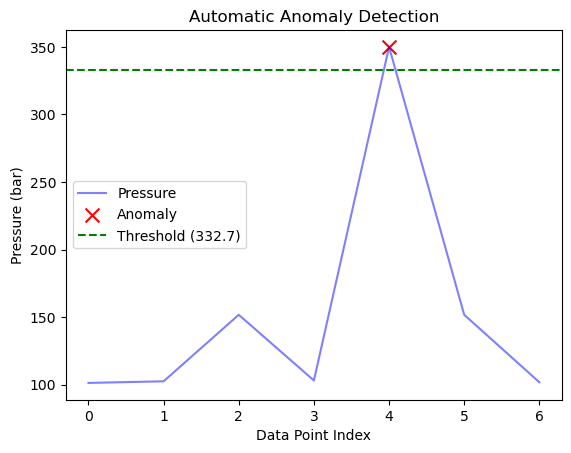

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["pressure_bar"], label="Pressure", color="blue", alpha=0.5)


for i in anomaly_index:
    plt.scatter(i, df["pressure_bar"][i], color="red", marker="x", s=100, label="Anomaly" if i == anomaly_index[0] else "")

plt.axhline(y=threshold, color='green', linestyle='--', label=f"Threshold ({threshold:.1f})")

plt.xlabel("Data Point Index")
plt.ylabel("Pressure (bar)")
plt.title("Automatic Anomaly Detection")
plt.legend()
plt.show()

In [ ]:
import pandas as pd


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv("cleaned_sensor_data_v1.csv")

In [ ]:
mean_p = df["pressure_bar"].mean()
std_p = df["pressure_bar"].std()
threshold = mean_p + 2 * std_p

In [ ]:
def detect_anomalies(data, limit):
    indices = [i for i in range(len(data)) if data[i] > limit] 
    return indices

In [ ]:
anomalies = detect_anomalies(df["pressure_bar"], threshold)

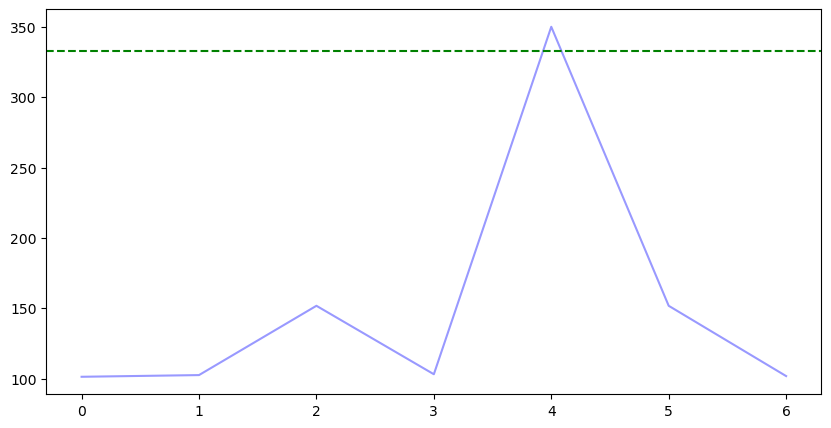

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["pressure_bar"], label="Pressure", color="blue", alpha=0.4)
plt.axhline(y=threshold, color='green', linestyle='--', label=f"Limit ({threshold:.2f})")

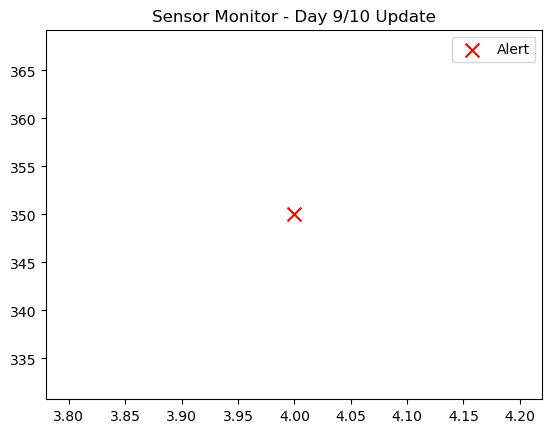

In [ ]:
plt.scatter(anomalies, df["pressure_bar"].iloc[anomalies], color="red", marker="x", s=100, label="Alert")

plt.title("Sensor Monitor - Day 9/10 Update")
plt.legend()
plt.show()

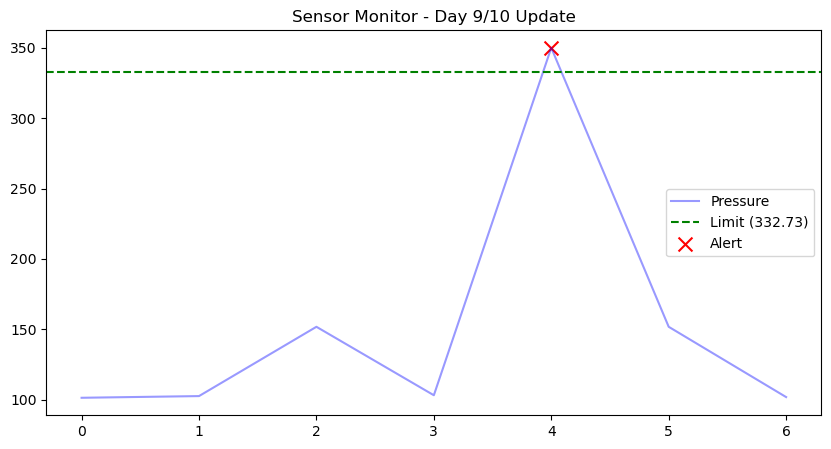

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["pressure_bar"], label="Pressure", color="blue", alpha=0.4)
plt.axhline(y=threshold, color='green', linestyle='--', label=f"Limit ({threshold:.2f})")

plt.scatter(anomalies, df["pressure_bar"].iloc[anomalies], color="red", marker="x", s=100, label="Alert")

plt.title("Sensor Monitor - Day 9/10 Update")
plt.legend()
plt.show()

In [ ]:
print(f" {anomalies}")

 [4]


In [ ]:
import pandas as pd
df=pd.read_csv("cleaned_sensor_data_v1.csv")

In [ ]:
df["pressure_bar"]=df["pressure_bar"].fillna(df["pressure_bar"].mean())


In [ ]:
df["pressure_smooth"]=df["pressure_bar"].rolling(window=3).mean()

In [ ]:
print("Data processed, first 10 rows:")
print(df[["pressure_bar", "pressure_smooth"]].head(10))

Data processed, first 10 rows:
   pressure_bar  pressure_smooth
0        101.30              NaN
1        102.50              NaN
2        151.74       118.513333
3        103.10       119.113333
4        350.00       201.613333
5        151.74       201.613333
6        101.80       201.180000


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df["pressure_bar"],label="original(Noisy)",color="lightgrey",linewidth=1, alpha=0.8)

NameError: name 'df' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
import pandas as pd
df=pd.read_csv("cleaned_sensor_data_v1.csv")

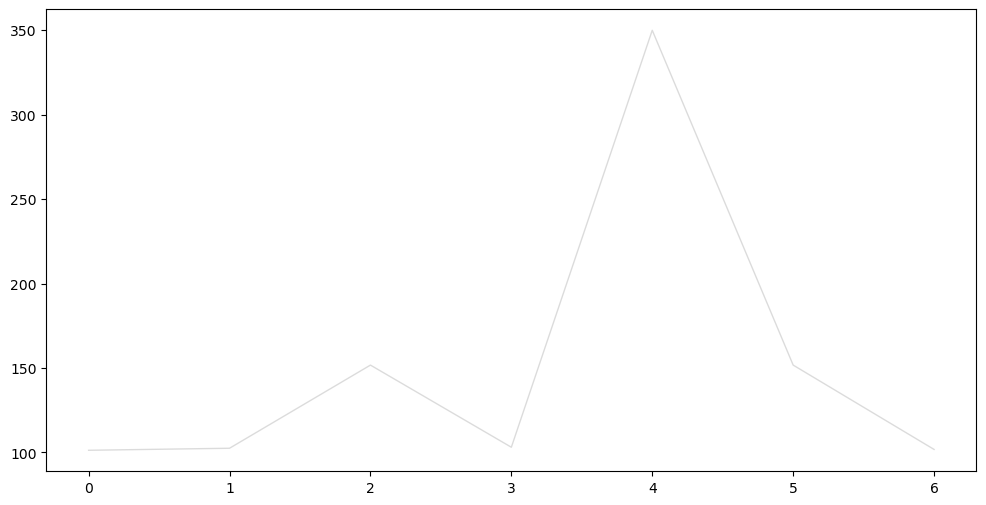

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df["pressure_bar"],label="original(Noisy)",color="lightgrey",linewidth=1, alpha=0.8)

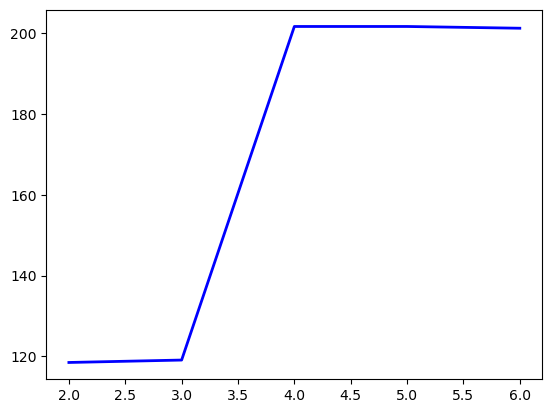

In [ ]:
plt.plot(df.index, df["pressure_smooth"], label="Smoothed (3-point Moving Average)", color="blue", linewidth=2)

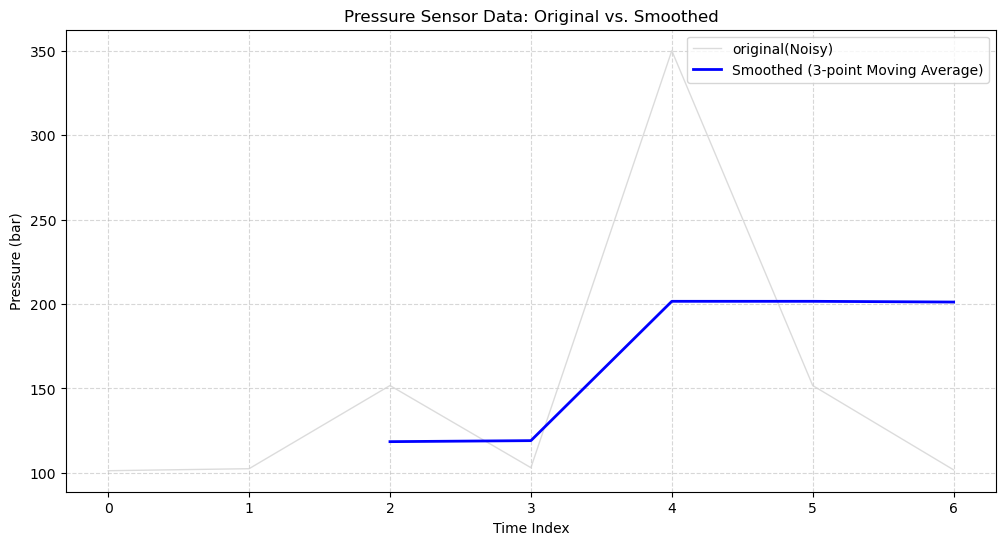

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df["pressure_bar"],label="original(Noisy)",color="lightgrey",linewidth=1, alpha=0.8)
plt.plot(df.index, df["pressure_smooth"], label="Smoothed (3-point Moving Average)", color="blue", linewidth=2)
plt.title("Pressure Sensor Data: Original vs. Smoothed")
plt.xlabel("Time Index")
plt.ylabel("Pressure (bar)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
plt.savefig("pressure_smoothing_comparison.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print("✅ Plot successfully generated and saved as 'pressure_comparison_plot.png'")

✅ Plot successfully generated and saved as 'pressure_comparison_plot.png'


In [21]:
# Statistical Summary Report
print("=" * 40)
print("Sensor Data Analysis Summary")
print("=" * 40)
print(f"Total data points: {len(df)}")
print(f"Mean pressure: {df['pressure_bar'].mean():.2f} bar")
print(f"Std deviation: {df['pressure_bar'].std():.2f}")
print(f"Max pressure: {df['pressure_bar'].max():.2f} bar")
print(f"Min pressure: {df['pressure_bar'].min():.2f} bar")
print(f"Anomalies detected: {len(anomaly_index)}")
print("=" * 40)

Sensor Data Analysis Summary
Total data points: 7
Mean pressure: 151.74 bar
Std deviation: 90.49
Max pressure: 350.00 bar
Min pressure: 101.30 bar


NameError: name 'anomaly_index' is not defined

In [22]:
# Statistical Summary Report
mean_p = df["pressure_bar"].mean()
std_p = df["pressure_bar"].std()
threshold = mean_p + 2 * std_p
anomaly_count = len(df[df["pressure_bar"] > threshold])

print("=" * 40)
print("Sensor Data Analysis Summary")
print("=" * 40)
print(f"Total data points: {len(df)}")
print(f"Mean pressure: {mean_p:.2f} bar")
print(f"Std deviation: {std_p:.2f}")
print(f"Max pressure: {df['pressure_bar'].max():.2f} bar")
print(f"Min pressure: {df['pressure_bar'].min():.2f} bar")
print(f"Anomalies detected: {anomaly_count}")
print("=" * 40)

Sensor Data Analysis Summary
Total data points: 7
Mean pressure: 151.74 bar
Std deviation: 90.49
Max pressure: 350.00 bar
Min pressure: 101.30 bar
Anomalies detected: 1
